## Script for statistics of Multilabel prediction

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
#setting filepaths the datasets

pi_results_filepath_ml = "../../output/PI_DataSe_multilabel_results.csv"

nnrti_results_filepath_ml = "../../output/NNRTI_DataSe_multilabel_results.csv"

nrti_results_filepath_ml = "../../output/NRTI_DataSe_multilabel_results.csv"

ini_results_filepath_ml = "../../output/INI_DataSe_multilabel_results.csv"



#creating lists with filepaths for later visualisation
filepath_list_ml = [pi_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, ini_results_filepath_ml]

pi_results_filepath_st = "../../output/PI_DataSe_Standard_comparison_results.csv"

nnrti_results_filepath_st = "../../output/NNRTI_DataSe_Standard_comparison_results.csv"

nrti_results_filepath_st = "../../output/NRTI_DataSe_Standard_comparison_results.csv"

ini_results_filepath_st = "../../output/INI_DataSe_Standard_comparison_results.csv"



#creating lists with filepaths for later visualisation
filepath_list_st = [pi_results_filepath_st, nnrti_results_filepath_st, nrti_results_filepath_st, ini_results_filepath_st]


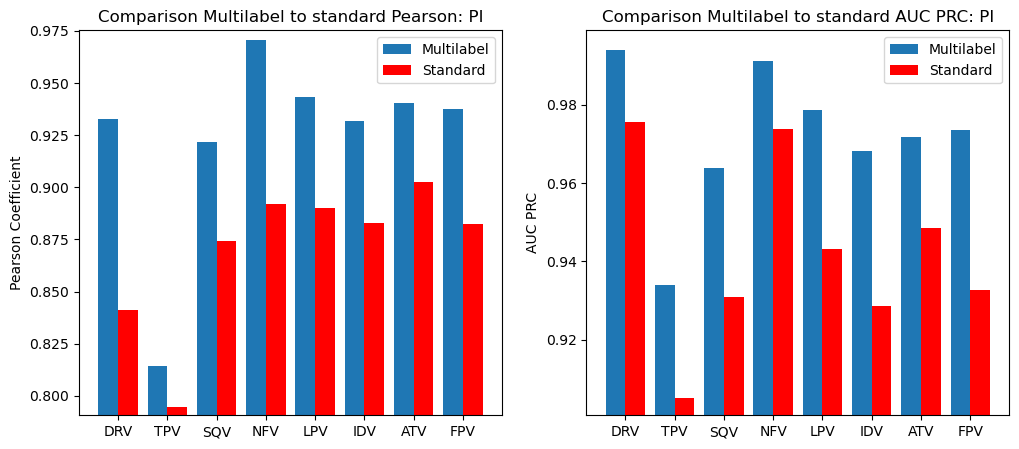

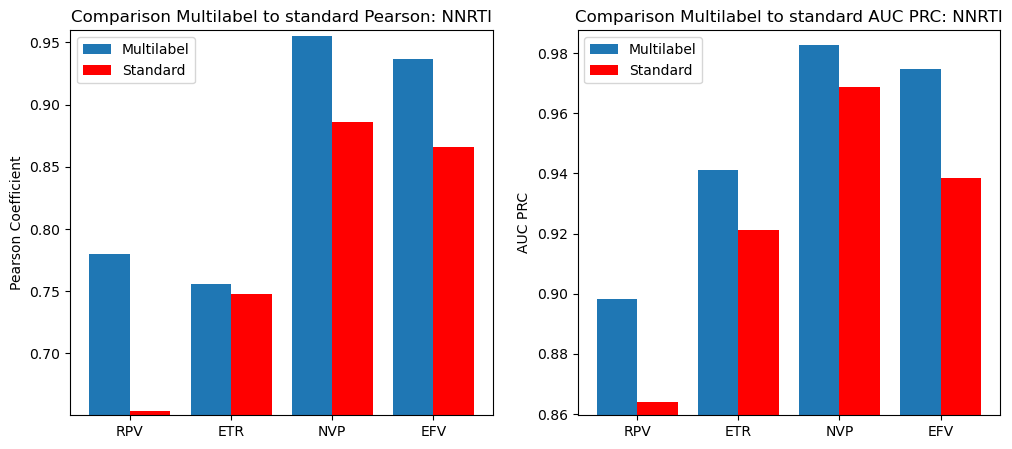

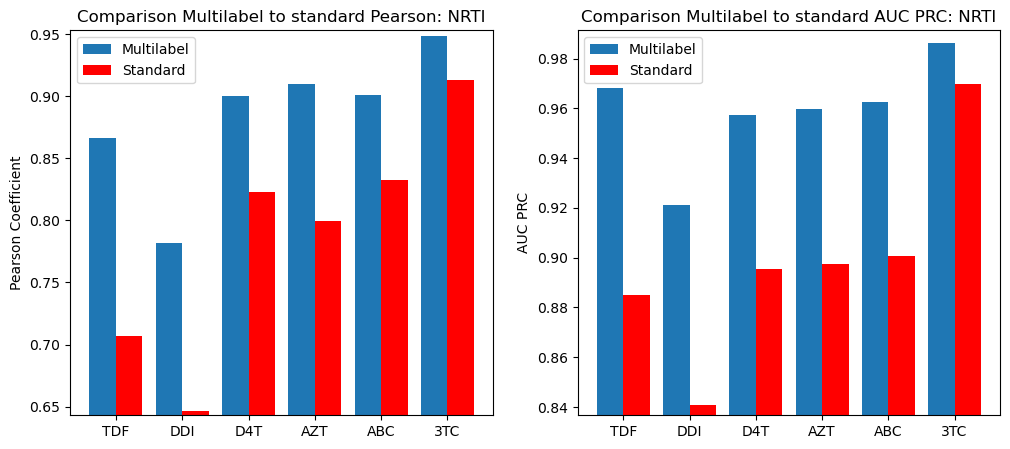

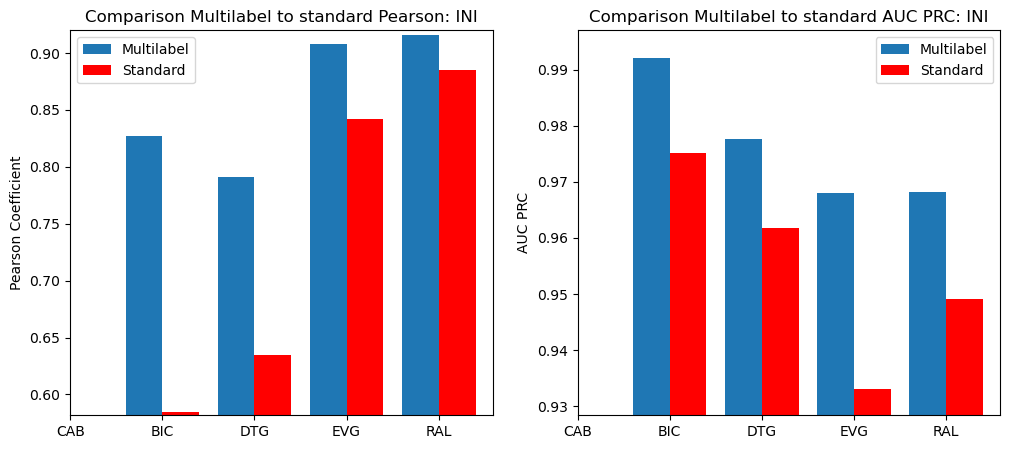

In [6]:


for filepath_ml, filepath_st in zip(filepath_list_ml, filepath_list_st):
    target_ml = pd.read_csv(filepath_ml)
    target_st = pd.read_csv(filepath_st)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    #fig.suptitle('Horizontally stacked subplots')

    w, x = 0.4, np.arange(len(target_ml["Drug"]))

    axs[0].bar(x - w/2, target_ml["Pearson"], width=w, label='Multilabel')
    axs[0].bar(x + w/2, target_st["Pearson"], width=w, color="r", label='Standard')

    axs[0].set_xticks(x)
    axs[0].set_xticklabels(target_ml["Drug"])
    axs[0].set_ylabel('Pearson Coefficient')
    axs[0].set_ylim(min(target_ml['Pearson'].min(), target_st['Pearson'].min())* 0.995, min(1.0, max(target_ml['Pearson'].max(), target_st['Pearson'].max())  * 1.005))
    axs[0].set_title('Comparison Multilabel to standard Pearson: ' + filepath_ml.split("/")[-1].split("_")[0])
    axs[0].legend()


    axs[1].bar(x - w/2, target_ml["AUC PRC"], width=w, label='Multilabel')
    axs[1].bar(x + w/2, target_st["AUC PRC"], width=w, color="r", label='Standard')

    axs[1].set_xticks(x)
    axs[1].set_xticklabels(target_ml["Drug"])
    axs[1].set_ylabel('AUC PRC')
    axs[1].set_ylim(min(target_ml['AUC PRC'].min(), target_st['AUC PRC'].min())* 0.995, min(1.0, max(target_ml['AUC PRC'].max(), target_st['AUC PRC'].max())  * 1.005))
    axs[1].set_title('Comparison Multilabel to standard AUC PRC: ' + filepath_ml.split("/")[-1].split("_")[0])
    axs[1].legend()


    plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")
